In [1]:
import numpy as np
import matplotlib.pyplot as plt
from unyt import kb,mp,K,cm,s

In [29]:
Y= 3e-3 # photodesorption yield
F0 = 1e8 / cm**2 / s # [photons cm-2 s-1]

def f_H20(nO,Tgas,G0):

    # 1. Compute the thermal velocity of oxygen
    vO = np.sqrt(8.*kb*Tgas*K/(np.pi*15.999*mp))
    
    # 2. Compute the fraction of surface covered with H20 ice
    nO = nO / cm**3.
    print(vO.to('cm/s'))
    
    return nO * vO / (G0*F0*Y)

print(np.sqrt(8.*kb*1*K/(np.pi*15.999*mp)))

36.24651037775416 m/s


11462.15300266333 cm/s
23552.48549126358 cm/s
31273.92195065881 cm/s
37435.23494698031 cm/s
42716.92213743089 cm/s
47413.859347822035 cm/s
51685.71059407782 cm/s
55630.488951423795 cm/s
59313.488536202305 cm/s
62780.79757134278 cm/s


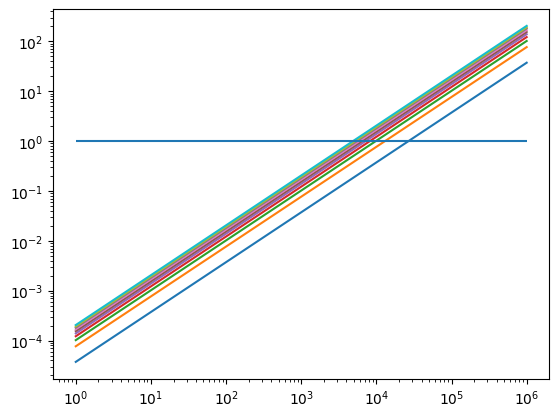

In [30]:
n = np.logspace(0,6,100)
Tgas = np.linspace(10,300,10)
# Abundance of oxygen at solar metallicity
xO = 10**(8.69-12.)
for i in range(0,len(Tgas)):
    f_ice = f_H20(n*xO,Tgas[i],1.0)/0.5
    plt.plot(n,f_ice,label=f'T={Tgas[i]} K')
plt.yscale('log')
plt.xscale('log')
plt.hlines(1,xmin=n[0],xmax=n[-1])

1146215.300266333 cm/s


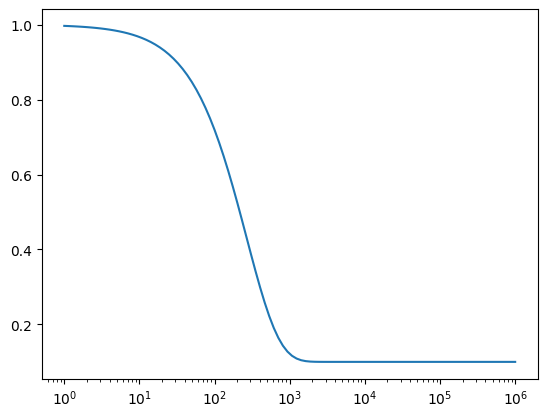

In [31]:
S_ice = 0.1
S_dust = 1.0

def sticking_coefficient(N_mono):

    return S_ice + (S_dust - S_ice) * np.exp(-N_mono)

f_ice = f_H20(n*xO,1e5,1.0)/0.5
plt.plot(n,sticking_coefficient(f_ice))
plt.xscale('log')


In [32]:
f_ice = f_H20(3.8813100436681223E-007,12541.017510671581,1.0)/0.5
print(f_ice)
print(sticking_coefficient(f_ice))

405912.65227684245 cm/s
1.0503152360893833e-06 dimensionless
0.9999990547167839
